In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv('pharma_mas_dataset.csv')

# Conversion des dates
df['Date'] = pd.to_datetime(df['Date'])
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'])

# Tri chronologique (essentiel pour les séries temporelles)
df = df.sort_values(by=['Pharmacy_ID', 'Drug_ID', 'Date']).reset_index(drop=True)

In [3]:
# 1. Création de variables de décalage (Lags) - Ce qui s'est vendu il y a 1, 2 ou 7 jours
df['Demand_Lag_1'] = df.groupby(['Pharmacy_ID', 'Drug_ID'])['Demand_Raw'].shift(1)
df['Demand_Lag_2'] = df.groupby(['Pharmacy_ID', 'Drug_ID'])['Demand_Raw'].shift(2)
df['Demand_Lag_7'] = df.groupby(['Pharmacy_ID', 'Drug_ID'])['Demand_Raw'].shift(7)

# 2. Moyennes mobiles (Rolling Averages) - Pour lisser le bruit et capter la tendance
df['Demand_Rolling_Mean_3d'] = df.groupby(['Pharmacy_ID', 'Drug_ID'])['Demand_Raw'].transform(lambda x: x.rolling(3).mean())
df['Demand_Rolling_Mean_7d'] = df.groupby(['Pharmacy_ID', 'Drug_ID'])['Demand_Raw'].transform(lambda x: x.rolling(7).mean())

# 3. Normalisation/Standardisation des prix et stocks (pour les futurs modèles d'IA)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Unit_Price_Scaled'] = scaler.fit_transform(df[['Unit_Price_MAD']])

# Gestion des valeurs manquantes générées par les lags
df = df.dropna().reset_index(drop=True)

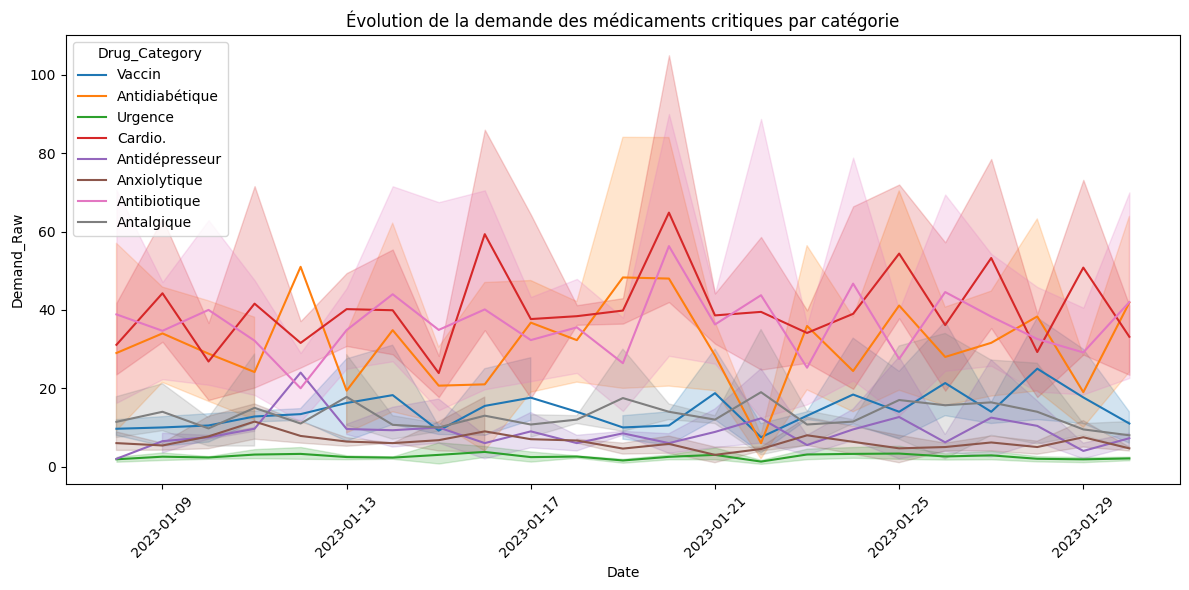

In [4]:
# Exemple de visualisation de la demande pour un médicament critique dans une ville
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['Is_Critical_Drug'] == 1].sample(1000, random_state=42),
             x='Date', y='Demand_Raw', hue='Drug_Category')
plt.title("Évolution de la demande des médicaments critiques par catégorie")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df.to_csv('pharma_mas_processed.csv', index=False)
print("Pipeline terminé. Fichier prêt pour le système multi-agents.")

Pipeline terminé. Fichier prêt pour le système multi-agents.
